In [1]:
# ===========================================
# NOTEBOOK 3: Model Evaluation & Unsupervised Learning
# ===========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans


In [2]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

print("Loaded shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Loaded shapes:
X_train: (100778, 41)
X_test: (25195, 41)
y_train: (100778,)
y_test: (25195,)


In [5]:
import joblib

rf_model = joblib.load("rf_model.pkl")
lgb_model = joblib.load("lgb_model.pkl")


=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9192
           1       1.00      1.00      1.00      2331
           2       0.99      0.96      0.97       199
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       0.80      0.79      0.79     25195
weighted avg       1.00      1.00      1.00     25195



c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


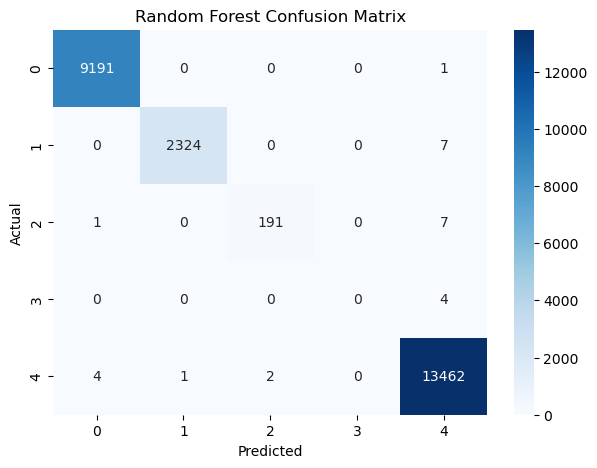

In [6]:
rf_preds = rf_model.predict(X_test)

print("=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, rf_preds))

rf_cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7,5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== LIGHTGBM REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9192
           1       1.00      1.00      1.00      2331
           2       0.99      0.95      0.97       199
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       0.80      0.79      0.79     25195
weighted avg       1.00      1.00      1.00     25195



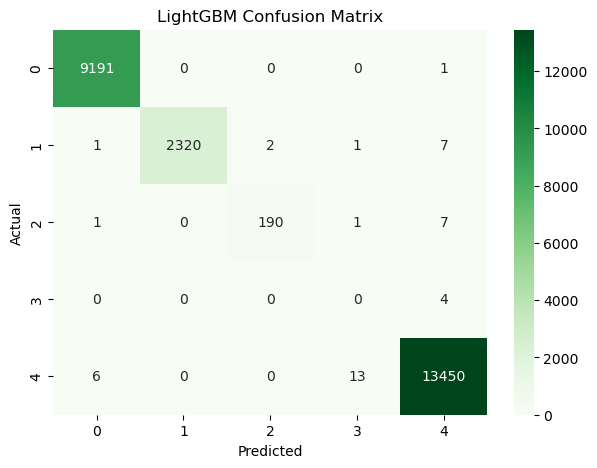

In [7]:
lgb_preds = lgb_model.predict(X_test)
lgb_preds = np.argmax(lgb_preds, axis=1)   # Multiclass output

print("=== LIGHTGBM REPORT ===")
print(classification_report(y_test, lgb_preds))

lgb_cm = confusion_matrix(y_test, lgb_preds)

plt.figure(figsize=(7,5))
sns.heatmap(lgb_cm, annot=True, fmt="d", cmap="Greens")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier()

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="accuracy",
    cv=3,
    verbose=1,
    n_jobs=-1
)



In [31]:
# ==========================================
# Ultra-Fast Manual Hyperparameter Tuning
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("Training Random Forest with manually tuned parameters...")

rf_model = RandomForestClassifier(
    n_estimators=150,      # good performance, fast
    max_depth=20,          # avoids overfitting
    min_samples_split=2,   # standard
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
print("\n Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(rf_model, "rf_model_tuned.pkl")
print("\n Random Forest saved as rf_model_tuned.pkl")


Training Random Forest with manually tuned parameters...

 Accuracy: 0.9987695971422902

 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9192
           1       1.00      1.00      1.00      2331
           2       0.98      0.96      0.97       199
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       0.80      0.79      0.79     25195
weighted avg       1.00      1.00      1.00     25195



c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\janha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Random Forest saved as rf_model_tuned.pkl


In [25]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

cluster_labels = kmeans.predict(X_test)


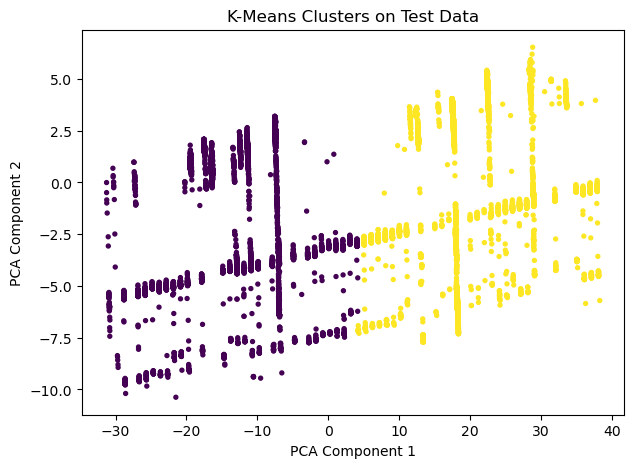

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=8)
plt.title("K-Means Clusters on Test Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [27]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

iso_pred = iso.predict(X_test)

iso_pred = np.where(iso_pred == -1, 1, 0)  # 1 = anomaly


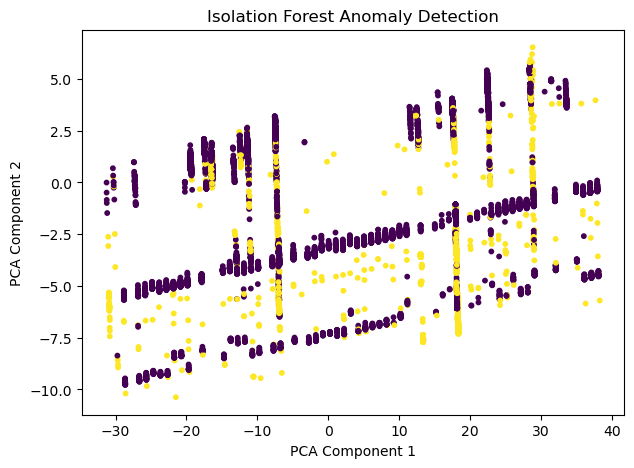

In [28]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=iso_pred, s=10)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [29]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_preds))

print("\nK-Means Cluster Count:", np.bincount(cluster_labels))
print("\nIsolation Forest Anomaly Label Count:", np.bincount(iso_pred))


Random Forest Accuracy: 0.9989283588013494
LightGBM Accuracy: 0.9982536217503473

K-Means Cluster Count: [16038  9157]

Isolation Forest Anomaly Label Count: [22638  2557]


In [30]:
np.save("rf_predictions.npy", rf_preds)
np.save("lgb_predictions.npy", lgb_preds)
np.save("iso_predictions.npy", iso_pred)
np.save("kmeans_clusters.npy", cluster_labels)
